In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/financial_fraud_detection_dataset.csv")
df.head()

/tmp/ipykernel_15555/2992682023.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/drive/MyDrive/financial_fraud_detection_dataset.csv")


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3.0,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7.0,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20.0,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6.0,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13.0,0.27,ACH,108.161.108.255,D7637601


In [ ]:
df.shape

(202123, 18)

In [ ]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount', 'transaction_type', 'merchant_category', 'location',
       'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction',
       'spending_deviation_score', 'velocity_score', 'geo_anomaly_score',
       'payment_channel', 'ip_address', 'device_hash'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202123 entries, 0 to 202122
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   transaction_id               202123 non-null  object 
 1   timestamp                    202123 non-null  object 
 2   sender_account               202123 non-null  object 
 3   receiver_account             202123 non-null  object 
 4   amount                       202123 non-null  float64
 5   transaction_type             202123 non-null  object 
 6   merchant_category            202122 non-null  object 
 7   location                     202122 non-null  object 
 8   device_used                  202122 non-null  object 
 9   is_fraud                     202122 non-null  object 
 10  fraud_type                   879 non-null     object 
 11  time_since_last_transaction  20861 non-null   float64
 12  spending_deviation_score     202122 non-null  float64
 13 

In [ ]:
df.describe()

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,202123.000000,20861.000000,202122.000000,202122.000000,202122.000000
mean,358.395973,21.653483,0.002200,10.484727,0.499667
std,469.327245,3575.103887,0.999102,5.768468,0.288707
min,0.010000,-8680.497974,-4.630000,1.000000,0.000000
25%,26.650000,-2538.808684,-0.680000,5.000000,0.250000
50%,138.250000,29.564395,-0.000000,10.000000,0.500000
75%,503.300000,2600.410666,0.680000,15.000000,0.750000
max,2833.230000,8706.600354,4.250000,20.000000,1.000000


In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
False,201243
True,879


In [ ]:
df['is_fraud'].value_counts(normalize=True)

,proportion
is_fraud,
False,0.995651
True,0.004349


In [ ]:
#Average Fraud Amount
df.groupby('is_fraud')['amount'].mean()


,amount
is_fraud,
False,358.359314
True,367.180489


In [ ]:
#Fraud by Trasaction Type
df.groupby("transaction_type")["is_fraud"].value_counts()

transaction_type  is_fraud
deposit           False       50269
                  True          227
payment           False       50306
                  True          195
transfer          False       50543
                  True          231
withdrawal        False       50125
                  True          226
Name: count, dtype: int64

In [ ]:
#Fraud by device
df.groupby("device_used")["is_fraud"].mean()

,is_fraud
device_used,
atm,0.004722
mobile,0.0046
pos,0.004035
web,0.004036


In [ ]:
df["fraud_type"].value_counts()

,count
fraud_type,
card_not_present,879


#EDA


In [ ]:
df["timestamp"]= pd.to_datetime(df["timestamp"])


In [ ]:
df["hour"]=df["timestamp"].dt.hour
df["day"]=df["timestamp"].dt.day
df["month"]=df["timestamp"].dt.month

In [ ]:
df["is_fraud"].value_counts()

,count
is_fraud,
False,201243
True,879


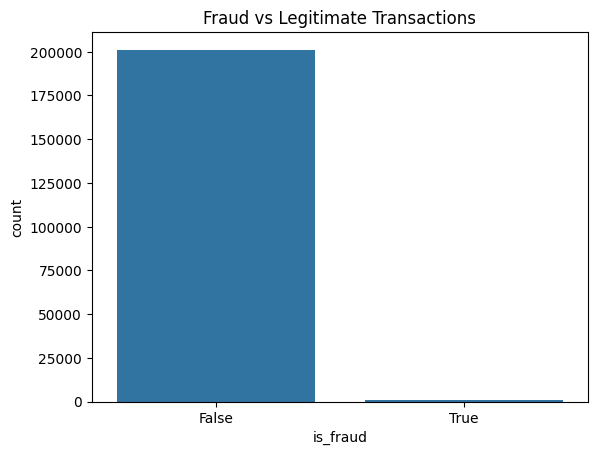

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='is_fraud',data=df)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

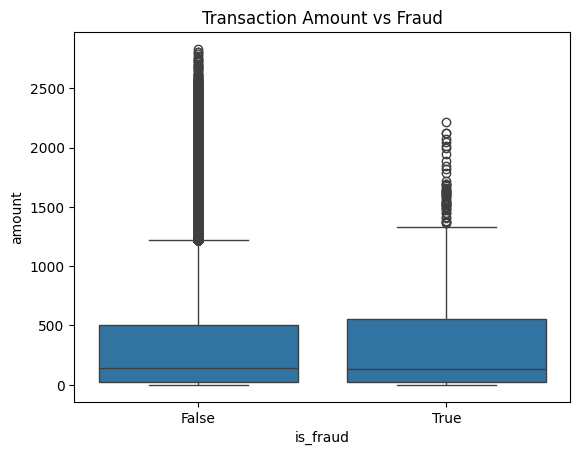

In [ ]:
sns.boxplot(x="is_fraud",y="amount",data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()


In [ ]:
fraud_rate_type=df.groupby("transaction_type")["is_fraud"].mean()
fraud_rate_type.sort_values(ascending=False)

,is_fraud
transaction_type,
transfer,0.00455
deposit,0.004495
withdrawal,0.004488
payment,0.003861


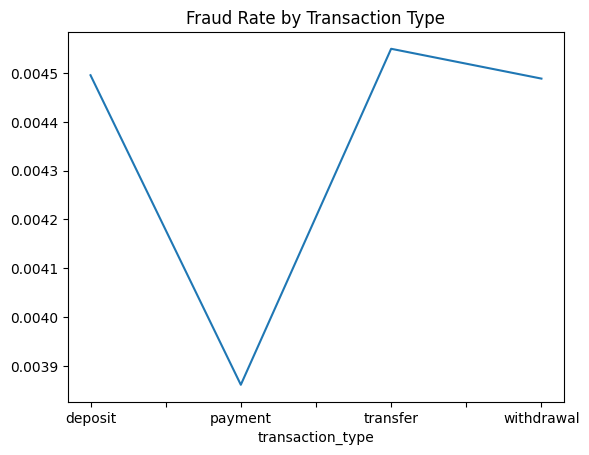

In [ ]:
fraud_rate_type.plot(kind="line")
plt.title("Fraud Rate by Transaction Type")
plt.show()

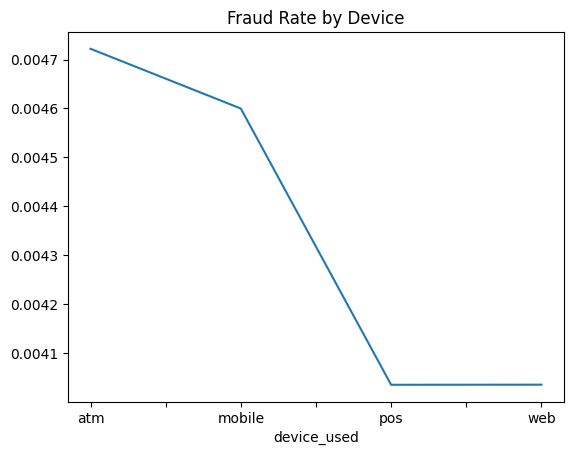

In [ ]:
device_fraud=df.groupby("device_used")["is_fraud"].mean()
device_fraud.plot(kind="line")
plt.title("Fraud Rate by Device")
plt.show()

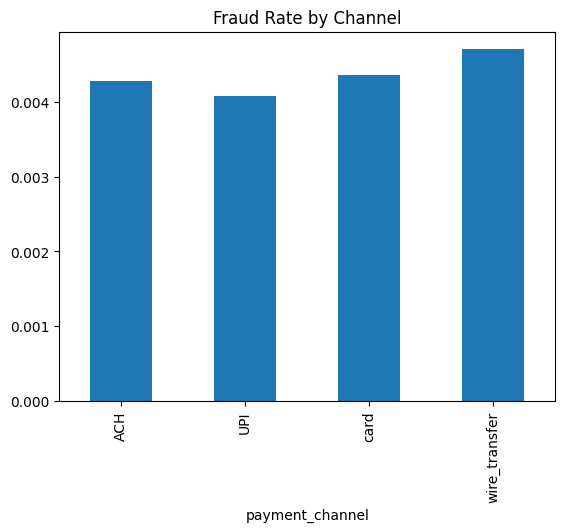

In [ ]:
channel_fraud=df.groupby("payment_channel")["is_fraud"].mean()
channel_fraud.plot(kind="bar")
plt.title("Fraud Rate by Channel")
plt.show()

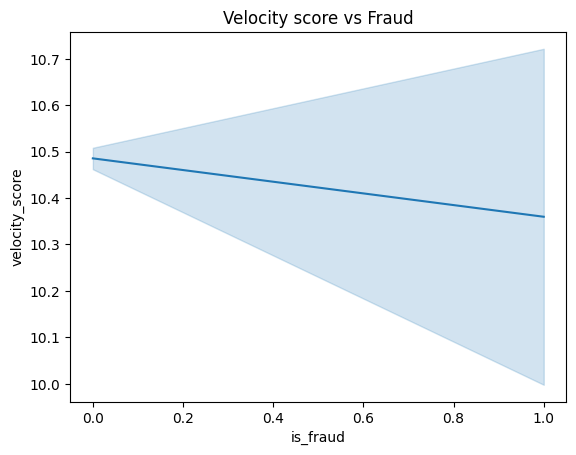

In [ ]:
sns.lineplot(x="is_fraud",y="velocity_score",data=df)
plt.title("Velocity score vs Fraud")
plt.show()

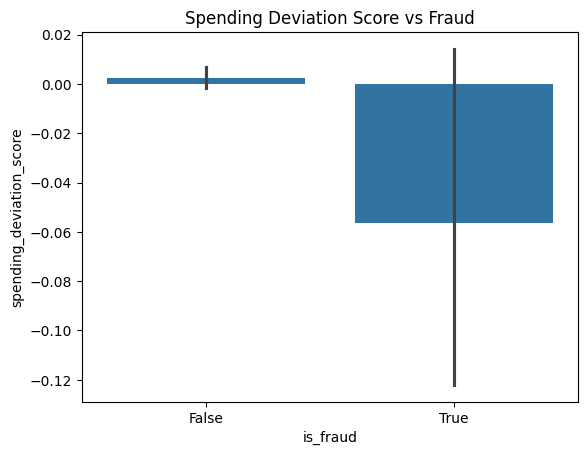

In [ ]:
sns.barplot(x="is_fraud",y="spending_deviation_score",data=df)
plt.title("Spending Deviation Score vs Fraud")
plt.show()

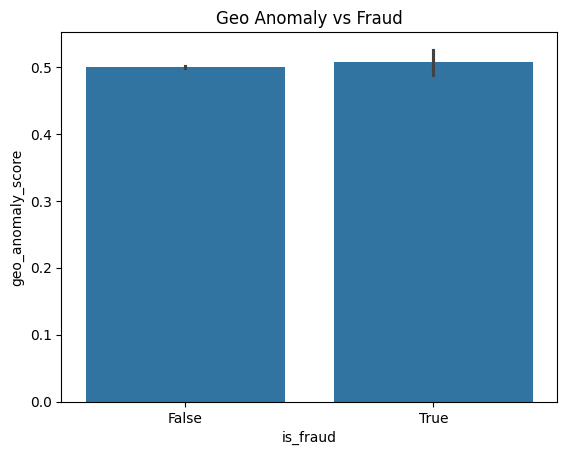

In [ ]:
sns.barplot(x="is_fraud",y="geo_anomaly_score",data=df)
plt.title("Geo Anomaly vs Fraud")
plt.show()

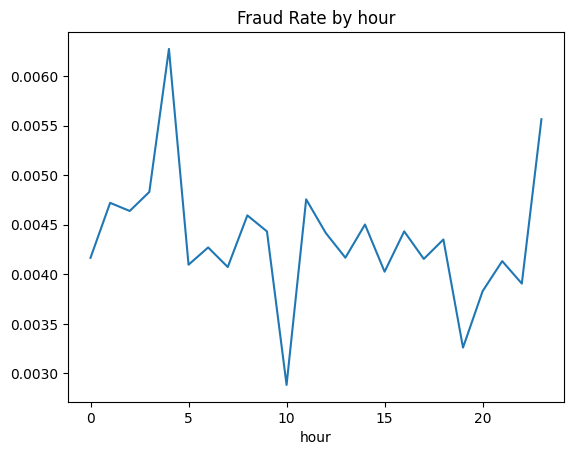

In [ ]:
#fraud by hour of hour
hour_fraud=df.groupby("hour")["is_fraud"].mean()
hour_fraud.plot()
plt.title("Fraud Rate by hour")
plt.show()

In [ ]:
#fraudtype
df['fraud_type'].value_counts()

,count
fraud_type,
card_not_present,879


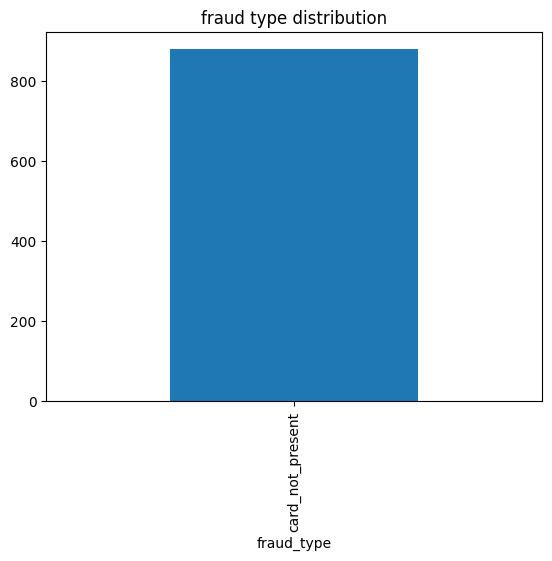

In [ ]:
df['fraud_type'].value_counts().plot(kind="bar")
plt.title("fraud type distribution")
plt.show()

#Data cleaning


In [ ]:
df.isnull().sum()

,0
transaction_id,0
timestamp,0
sender_account,0
receiver_account,0
amount,0
transaction_type,0
merchant_category,1
location,1
device_used,1
is_fraud,1


In [ ]:
df["amount"] = df["amount"].fillna(df["amount"].median())
df["velocity_score"] = df["velocity_score"].fillna(df["velocity_score"].median())
df["spending_deviation_score"] = df["spending_deviation_score"].fillna(df["spending_deviation_score"].median())
df["geo_anomaly_score"] = df["geo_anomaly_score"].fillna(df["geo_anomaly_score"].median())

In [ ]:
df["device_used"].fillna("Unknonw")
df["payment_channel"].fillna("Unknown")
df['merchant_category'].fillna("Unknown")

,merchant_category
0,utilities
1,online
2,other
3,online
4,utilities
...,...
202118,retail
202119,other
202120,grocery
202121,retail


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month

In [ ]:
df=df.drop(columns=["timestamp"])

In [ ]:
#Save this cleaned data for future analysis
df.to_csv('cleaned_financial_fraud_data.csv', index=False)

In [ ]:
df=df.drop(columns=[
    "transaction_id",
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash"
])

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/cleaned_financial_fraud_data.csv")
df.head()

/tmp/ipykernel_15555/4166891523.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/drive/MyDrive/cleaned_financial_fraud_data.csv")


,transaction_id,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,hour,day,month
0,T100000,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3.0,0.22,card,13.101.214.112,D8536477,9,22,8
1,T100001,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7.0,0.96,ACH,172.52.47.194,D2622631,1,4,8
2,T100002,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20.0,0.89,card,185.98.35.23,D4823498,11,12,5
3,T100003,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6.0,0.37,wire_transfer,107.136.36.87,D9961380,6,10,10
4,T100004,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13.0,0.27,ACH,108.161.108.255,D7637601,8,24,9


In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "transaction_type",
        "merchant_category",
        "location",
        "device_used",
        "payment_channel"
    ],
    drop_first=True
)

In [ ]:
df=df.drop(columns=["fraud_type"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202123 entries, 0 to 202122
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   transaction_id                   202123 non-null  object 
 1   sender_account                   202123 non-null  object 
 2   receiver_account                 202123 non-null  object 
 3   amount                           202123 non-null  float64
 4   is_fraud                         202122 non-null  object 
 5   time_since_last_transaction      20861 non-null   float64
 6   spending_deviation_score         202123 non-null  float64
 7   velocity_score                   202123 non-null  float64
 8   geo_anomaly_score                202123 non-null  float64
 9   ip_address                       202122 non-null  object 
 10  device_hash                      202122 non-null  object 
 11  hour                             202123 non-null  int64  
 12  da

In [ ]:
df.head()

,transaction_id,sender_account,receiver_account,amount,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,ip_address,...,location_Tokyo,location_Toronto,device_used_atm,device_used_mobile,device_used_pos,device_used_web,payment_channel_UPI,payment_channel_Unknown,payment_channel_card,payment_channel_wire_transfer
0,T100000,ACC877572,ACC388389,343.78,False,NaN,-0.21,3.0,0.22,13.101.214.112,...,True,False,False,True,False,False,False,False,True,False
1,T100001,ACC895667,ACC944962,419.65,False,NaN,-0.14,7.0,0.96,172.52.47.194,...,False,True,True,False,False,False,False,False,False,False
2,T100002,ACC733052,ACC377370,2773.86,False,NaN,-1.78,20.0,0.89,185.98.35.23,...,False,False,False,False,True,False,False,False,True,False
3,T100003,ACC996865,ACC344098,1666.22,False,NaN,-0.60,6.0,0.37,107.136.36.87,...,False,False,False,False,True,False,False,False,False,True
4,T100004,ACC584714,ACC497887,24.43,False,NaN,0.79,13.0,0.27,108.161.108.255,...,False,True,False,True,False,False,False,False,False,False


In [ ]:
x=df.drop(columns=["is_fraud"])
y=df["is_fraud"]


#Feature Engineering

In [ ]:
df["amount_category"]=pd.cut(
    df["amount"],
    bins=[0, 100, 500, 1000, 2000, df["amount"].max()],
    labels=["very low","low","medium","high","very high"]
)

In [ ]:
df=pd.get_dummies(df,columns=["amount_category"])

In [ ]:
df["high_velocity_flag"] = (df["velocity_score"] > df["velocity_score"].mean()).astype(int)

In [ ]:
df["spending_anomaly_flag"] = (df["spending_deviation_score"] > df["spending_deviation_score"].mean()).astype(int)

In [ ]:
df["combined_risk_score"] = (
    df["velocity_score"] +
    df["spending_deviation_score"] +
    df["geo_anomaly_score"]
)

In [ ]:
#time based fraud indicator
df["night_transaction"] = ((df["hour"] >= 0) & (df["hour"] <= 5)).astype(int)

In [ ]:
df["rapid_transaction_flag"] = (df["time_since_last_transaction"] < 60).astype(int)

In [ ]:

device_risk_mapping = {
    "web": 3,
    "mobile": 2,
    "pos": 1,
    "atm": 1
}

df["device_used_risk"] = 0

df.loc[df["device_used_web"] == True, "device_used_risk"] = device_risk_mapping["web"]
df.loc[df["device_used_mobile"] == True, "device_used_risk"] = device_risk_mapping["mobile"]
df.loc[df["device_used_pos"] == True, "device_used_risk"] = device_risk_mapping["pos"]
df.loc[df["device_used_atm"] == True, "device_used_risk"] = device_risk_mapping["atm"]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202123 entries, 0 to 202122
Data columns (total 51 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   transaction_id                   202123 non-null  object 
 1   sender_account                   202123 non-null  object 
 2   receiver_account                 202123 non-null  object 
 3   amount                           202123 non-null  float64
 4   is_fraud                         202122 non-null  object 
 5   time_since_last_transaction      20861 non-null   float64
 6   spending_deviation_score         202123 non-null  float64
 7   velocity_score                   202123 non-null  float64
 8   geo_anomaly_score                202123 non-null  float64
 9   ip_address                       202122 non-null  object 
 10  device_hash                      202122 non-null  object 
 11  hour                             202123 non-null  int64  
 12  da

In [ ]:
df=df.drop(columns=[
    "transaction_id",
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash"
], errors='ignore')

In [ ]:
df.head()

,amount,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,hour,day,month,transaction_type_payment,...,amount_category_low,amount_category_medium,amount_category_high,amount_category_very high,high_velocity_flag,spending_anomaly_flag,combined_risk_score,night_transaction,rapid_transaction_flag,device_used_risk
0,343.78,False,NaN,-0.21,3.0,0.22,9,22,8,False,...,True,False,False,False,0,0,3.01,0,0,2
1,419.65,False,NaN,-0.14,7.0,0.96,1,4,8,False,...,True,False,False,False,0,0,7.82,1,0,1
2,2773.86,False,NaN,-1.78,20.0,0.89,11,12,5,False,...,False,False,False,True,1,0,19.11,0,0,1
3,1666.22,False,NaN,-0.60,6.0,0.37,6,10,10,False,...,False,False,True,False,0,0,5.77,0,0,1
4,24.43,False,NaN,0.79,13.0,0.27,8,24,9,False,...,False,False,False,False,1,1,14.06,0,0,2


#Model Training

In [ ]:
from sklearn.model_selection import train_test_split
df_cleaned = df.dropna(subset=['is_fraud']).copy()


df_cleaned = df_cleaned.drop(columns=['time_since_last_transaction'])

x = df_cleaned.drop("is_fraud", axis=1)
y = df_cleaned['is_fraud']

y = y.astype(bool).astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
#Synthetic Minority Oversampling
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
model_lr=LogisticRegression(max_iter=1000)
model_lr.fit(x_train_resampled,y_train_resampled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_rf.fit(x_train_resampled,y_train_resampled)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred=model_rf.predict(x_test)

In [ ]:
#Model Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     40249
           1       0.00      0.00      0.00       176

    accuracy                           1.00     40425
   macro avg       0.50      0.50      0.50     40425
weighted avg       0.99      1.00      0.99     40425



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


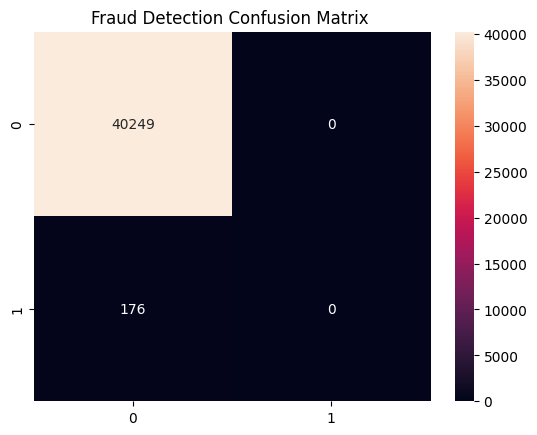

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Fraud Detection Confusion Matrix ")
plt.show()

In [ ]:
#Which features detect fraud
import pandas as pd

importance = model_rf.feature_importances_

feature_importance = pd.DataFrame({
    "feature": x.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(10))

                          feature  importance
28                device_used_web    0.086002
43               device_used_risk    0.077112
42         rapid_transaction_flag    0.076329
39          spending_anomaly_flag    0.047866
26             device_used_mobile    0.046814
1        spending_deviation_score    0.044100
27                device_used_pos    0.041412
25                device_used_atm    0.037822
0                          amount    0.035608
32  payment_channel_wire_transfer    0.033203


In [ ]:
import joblib
joblib.dump(model_rf,"fraud_detection_model.pkl")


['fraud_detection_model.pkl']

#Fraud Risk Score

In [ ]:
df["risk_score"] = (
    df["velocity_score"] * 0.3 +
    df["spending_deviation_score"] * 0.3 +
    df["geo_anomaly_score"] * 0.4
)

In [ ]:
df["risk_score"] = 100 * (df["risk_score"] - df["risk_score"].min()) / (df["risk_score"].max() - df["risk_score"].min())

In [ ]:
def risk_level(score):
  if score < 30:
    return "Low Risk"
  elif score <70:
    return "Medium Risk"
  else:
    return "High Risk"
df['risk_level'] = df['risk_score'].apply(risk_level)


#Fraud detection often uses unsupervised learning

In [ ]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

anomaly_features = [
    "amount",
    "velocity_score",
    "spending_deviation_score",
    "geo_anomaly_score"
]

df["anomaly_flag"] = iso_model.fit_predict(df[anomaly_features])

In [ ]:
#Fraud Indicator
df["anomaly_flag"] = df["anomaly_flag"].map({1:0, -1:1})

#Data Mining

In [ ]:
from sklearn.cluster import KMeans

cluster_features = [
    "amount",
    "velocity_score",
    "spending_deviation_score",
    "geo_anomaly_score"
]

kmeans = KMeans(n_clusters=4, random_state=42)

df["fraud_cluster"] = kmeans.fit_predict(df[cluster_features])

In [ ]:
#Combine signals
df["suspicious_flag"] = (
    (df["risk_score"] > 70) |
    (df["anomaly_flag"] == 1) |
    (df["high_velocity_flag"] == 1)
).astype(int)

In [ ]:
dashboard_df = df[[
    "amount",
    "risk_score",
    "risk_level",
    "fraud_cluster",
    "suspicious_flag",
    "is_fraud"
]]

In [ ]:
dashboard_df.to_csv("fraud_dashboard_dataset.csv", index=False)

#Model Building

In [ ]:
import joblib
import pandas as pd

model = joblib.load("/content/drive/MyDrive/fraud_detection_model.pkl")

In [ ]:
new_transaction = pd.DataFrame({
    "amount":[4500],
    "velocity_score":[0.8],
    "spending_deviation_score":[0.7],
    "geo_anomaly_score":[0.9],
    "time_since_last_transaction":[30],
    "hour":[2]
})

In [ ]:
'''Rolling windows

Transaction sequences

Behavioral profiling
'''